# Industrial Machine Failure Prediction — AI4I 2020

## Complete Machine Learning Pipeline

**Goal:** Predict whether an industrial machine will experience a failure from its operating conditions.

### Workflow
Data loading → data-quality audit → EDA → leakage check → feature engineering → train/test split → preprocessing → baseline models → GridSearchCV → model comparison → detailed evaluation → threshold analysis → feature importance → error analysis.

### Models
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- XGBoost
- SVM


> `UDI`, `Product ID`, and the failure-mode indicators (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`) are excluded from the predictive features to avoid identifier-driven learning and target leakage.

### GitHub / Local Execution Note
The dataset is expected at `data/ai4i2020.csv`. Install dependencies with `pip install -r requirements.txt` before running the notebook.

In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, ParameterGrid
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, roc_curve,
    precision_recall_curve
)

from xgboost import XGBClassifier

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

## 1. Load the Single CSV

In [3]:
DATA_PATH = Path("data/ai4i2020.csv")
df = pd.read_csv("data/ai4i2020.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 2. Data Understanding

In [4]:
print("Columns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nDataset information:")
df.info()

Columns:
1. UDI
2. Product ID
3. Type
4. Air temperature [K]
5. Process temperature [K]
6. Rotational speed [rpm]
7. Torque [Nm]
8. Tool wear [min]
9. Machine failure
10. TWF
11. HDF
12. PWF
13. OSF
14. RNF

Data types:


,Data Type
UDI,int64
Product ID,object
Type,object
Air temperature [K],float64
Process temperature [K],float64
Rotational speed [rpm],int64
Torque [Nm],float64
Tool wear [min],int64
Machine failure,int64
TWF,int64



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes

In [5]:
summary = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2),
    "Unique Values": df.nunique()
})
display(summary)

,Data Type,Missing Values,Missing %,Unique Values
UDI,int64,0,0.0,10000
Product ID,object,0,0.0,10000
Type,object,0,0.0,3
Air temperature [K],float64,0,0.0,93
Process temperature [K],float64,0,0.0,82
Rotational speed [rpm],int64,0,0.0,941
Torque [Nm],float64,0,0.0,577
Tool wear [min],int64,0,0.0,246
Machine failure,int64,0,0.0,2
TWF,int64,0,0.0,2


In [6]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
UDI,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
Product ID,10000,10000,L57163,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,10000,3,L,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air temperature [K],10000.0,NaN,NaN,NaN,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,NaN,NaN,NaN,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,NaN,NaN,NaN,1538.7761,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,NaN,NaN,NaN,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,NaN,NaN,NaN,107.951,63.654147,0.0,53.0,108.0,162.0,253.0
Machine failure,10000.0,NaN,NaN,NaN,0.0339,0.180981,0.0,0.0,0.0,0.0,1.0
TWF,10000.0,NaN,NaN,NaN,0.0046,0.067671,0.0,0.0,0.0,0.0,1.0


## 3. Data Quality Audit

In [7]:
missing_total = df.isna().sum().sum()
duplicates = df.duplicated().sum()
infinite_total = np.isinf(df.select_dtypes(include=np.number)).sum().sum()

print("Missing values:", missing_total)
print("Duplicate rows:", duplicates)
print("Infinite numerical values:", infinite_total)

if missing_total == 0:
    print("✓ No missing values.")
if duplicates == 0:
    print("✓ No duplicate rows.")
if infinite_total == 0:
    print("✓ No infinite numerical values.")

Missing values: 0
Duplicate rows: 0
Infinite numerical values: 0
✓ No missing values.
✓ No duplicate rows.
✓ No infinite numerical values.


## 4. Target Analysis

,Count,Percentage
No Failure,9661,96.61
Failure,339,3.39


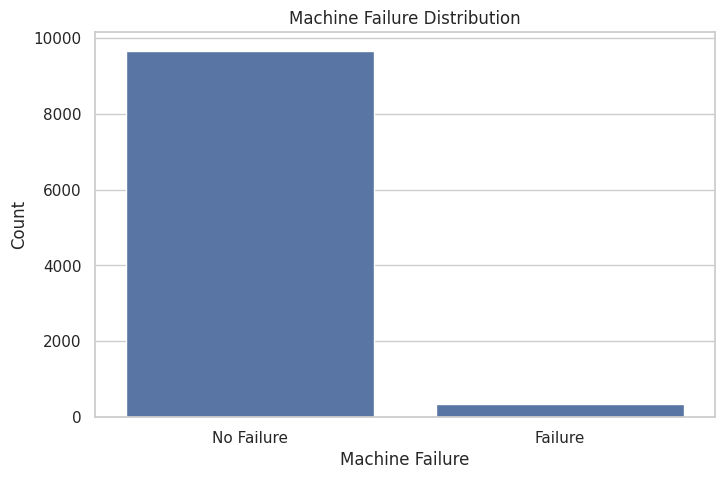

Failure rate: 3.39%


In [8]:
target_counts = df["Machine failure"].value_counts().sort_index()
target_pct = df["Machine failure"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_pct.round(2)
})
target_summary.index = ["No Failure", "Failure"]

display(target_summary)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Machine failure")
plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Count")
plt.xticks([0, 1], ["No Failure", "Failure"])
plt.show()

print(f"Failure rate: {df['Machine failure'].mean() * 100:.2f}%")

## 5. Product Type Analysis

,Count
Type,
L,6000
M,2997
H,1003


,Total,Failures,Failure_Rate
Type,,,
H,1003,21,2.09
L,6000,235,3.92
M,2997,83,2.77


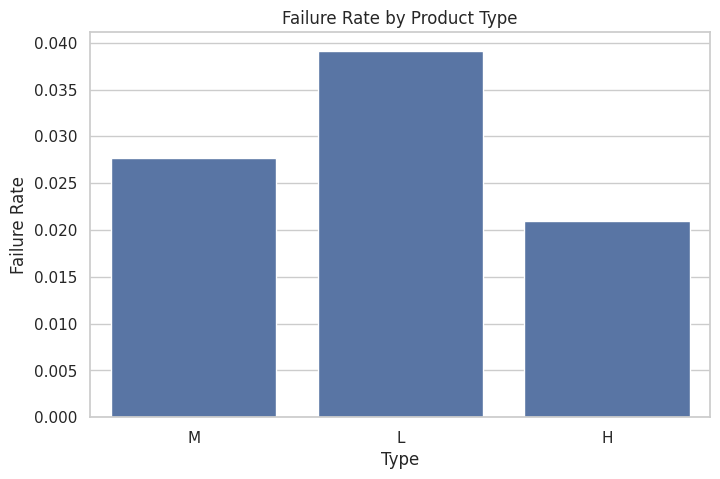

In [9]:
display(df["Type"].value_counts().to_frame("Count"))

failure_by_type = df.groupby("Type")["Machine failure"].agg(
    Total="count",
    Failures="sum",
    Failure_Rate="mean"
)
failure_by_type["Failure_Rate"] *= 100

display(failure_by_type.round(2))

plt.figure(figsize=(8, 5))
sns.barplot(
    data=df, x="Type", y="Machine failure",
    estimator=np.mean, errorbar=None
)
plt.title("Failure Rate by Product Type")
plt.ylabel("Failure Rate")
plt.show()

## 6. Numerical EDA

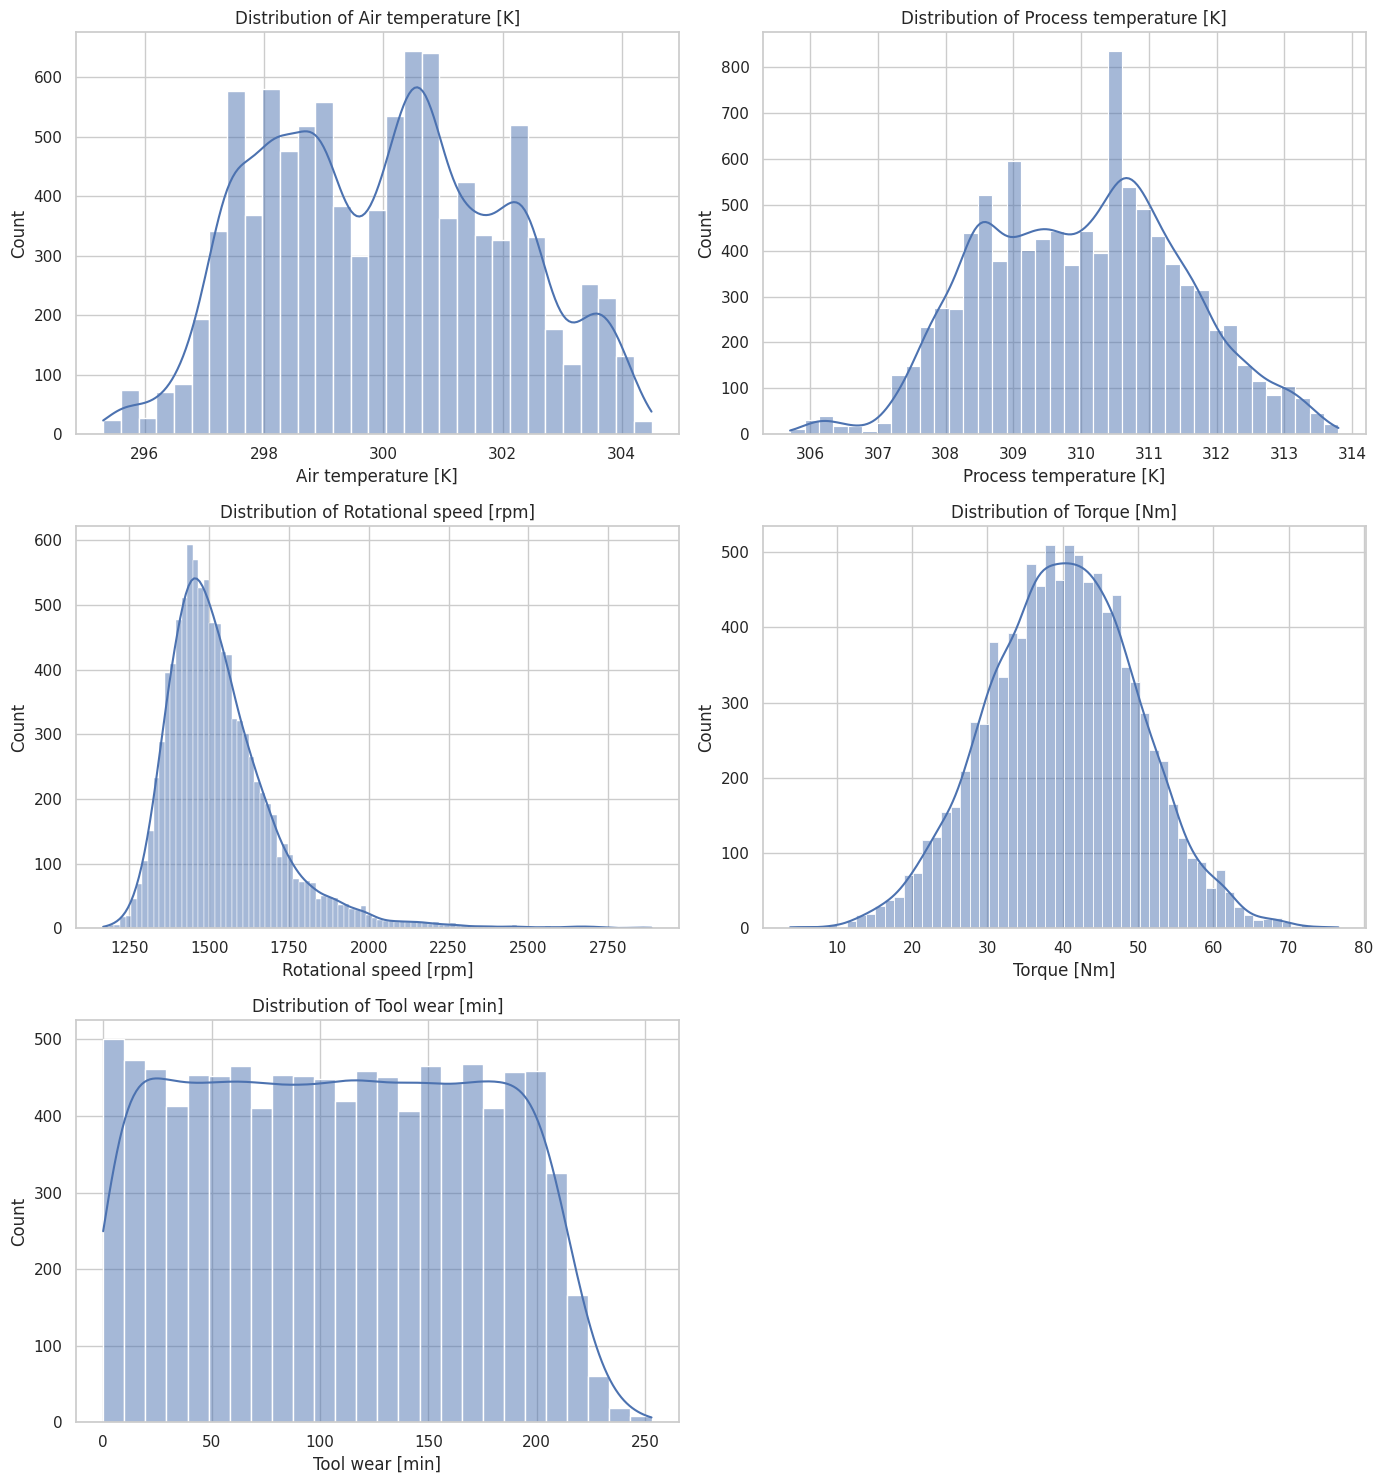

In [10]:
numeric_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

fig, axes = plt.subplots(3, 2, figsize=(14, 15))

for ax, col in zip(axes.ravel(), numeric_columns):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")

axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

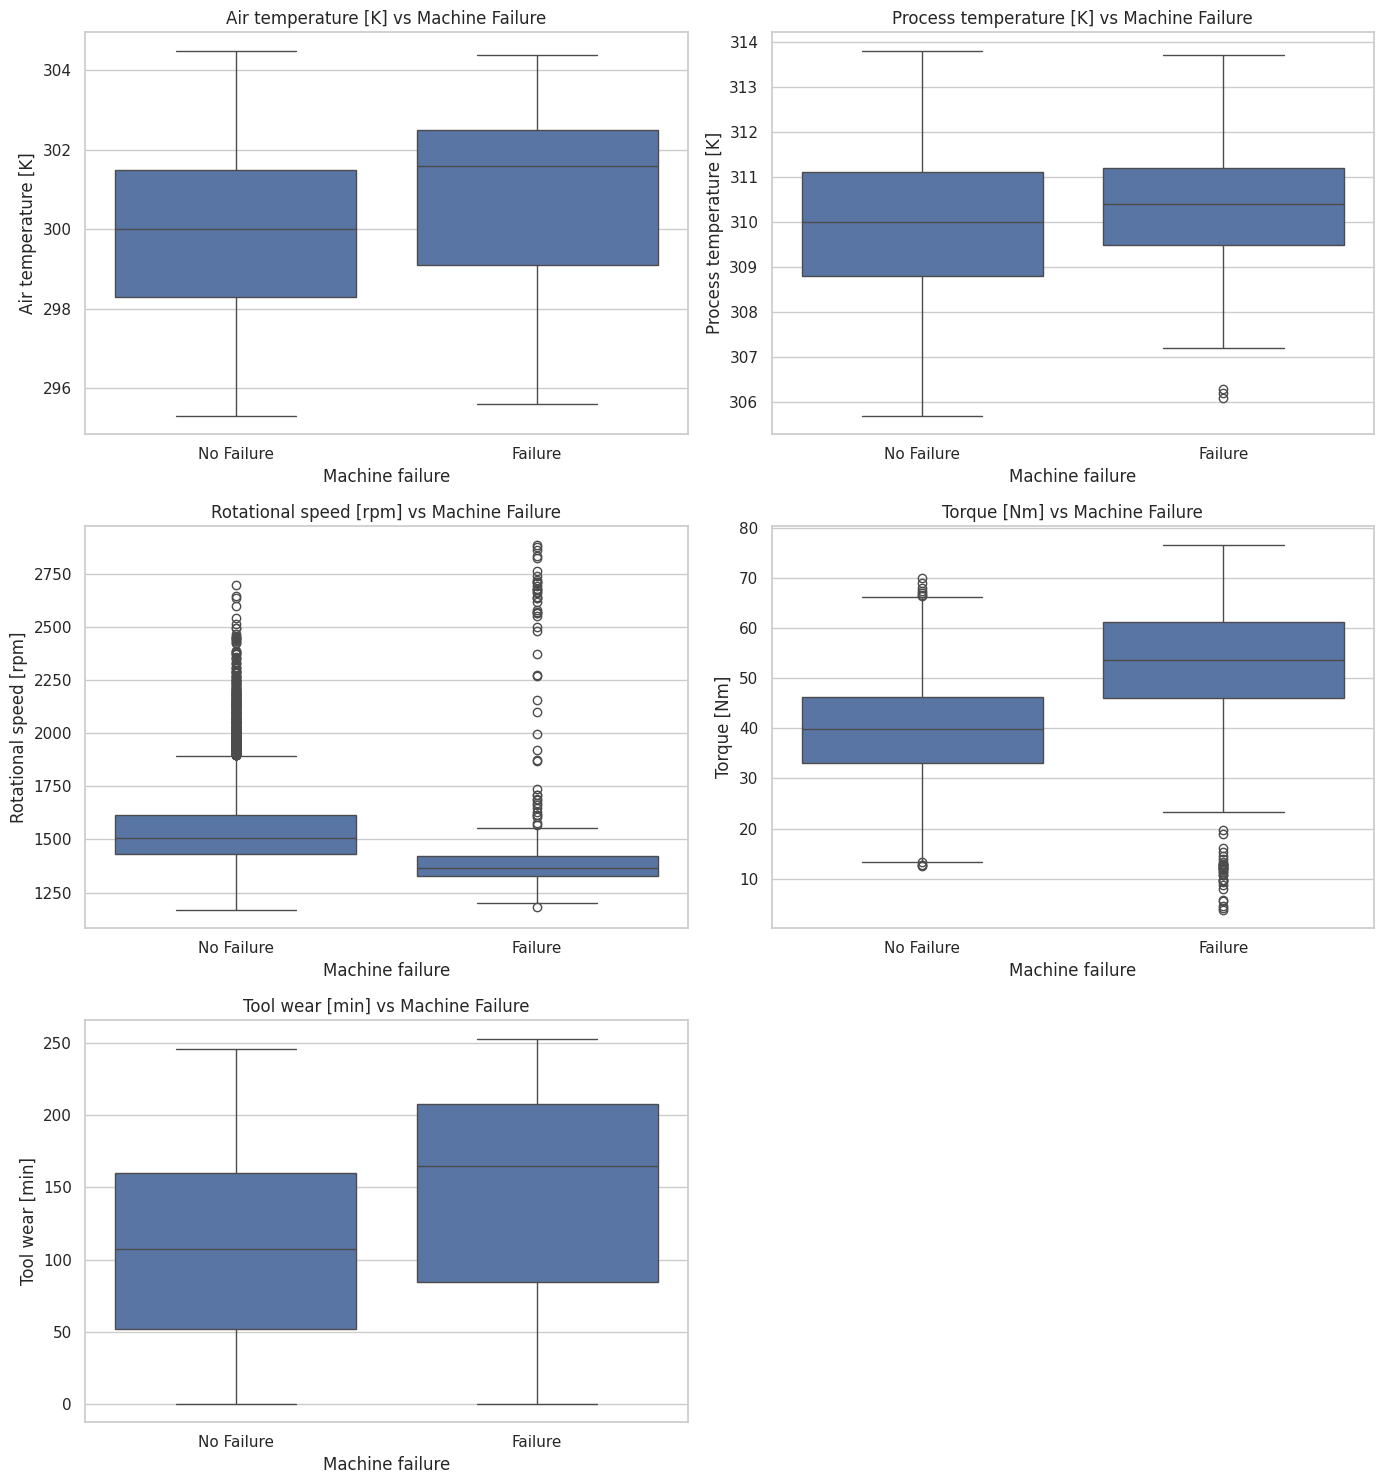

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

for ax, col in zip(axes.ravel(), numeric_columns):
    sns.boxplot(data=df, x="Machine failure", y=col, ax=ax)
    ax.set_title(f"{col} vs Machine Failure")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No Failure", "Failure"])

axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

## 7. Relationship Analysis

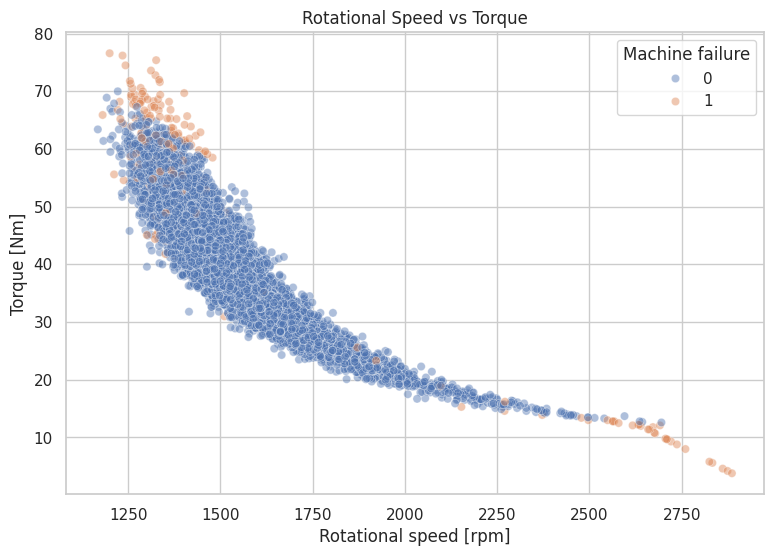

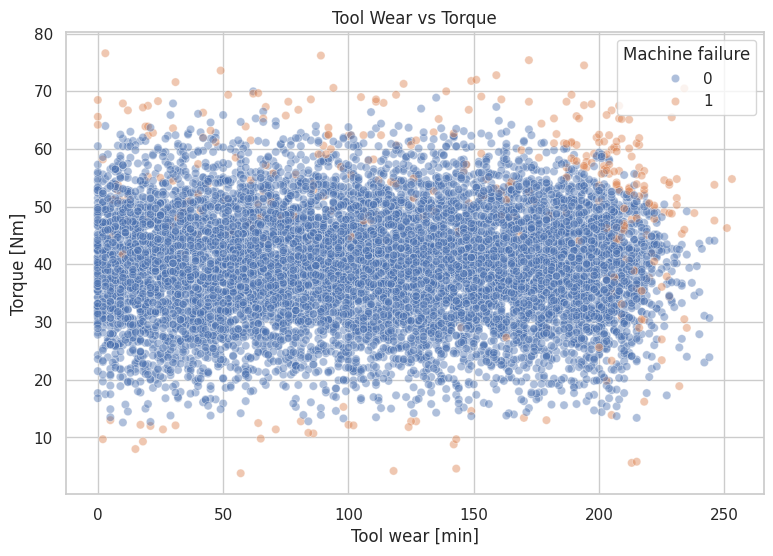

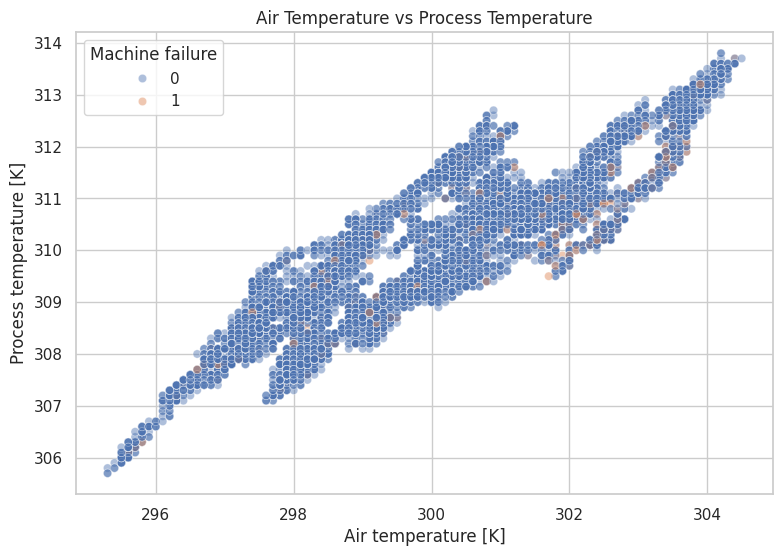

In [12]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="Rotational speed [rpm]",
    y="Torque [Nm]",
    hue="Machine failure",
    alpha=0.45
)
plt.title("Rotational Speed vs Torque")
plt.show()

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="Tool wear [min]",
    y="Torque [Nm]",
    hue="Machine failure",
    alpha=0.45
)
plt.title("Tool Wear vs Torque")
plt.show()

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="Air temperature [K]",
    y="Process temperature [K]",
    hue="Machine failure",
    alpha=0.45
)
plt.title("Air Temperature vs Process Temperature")
plt.show()

## 8. Correlation Analysis

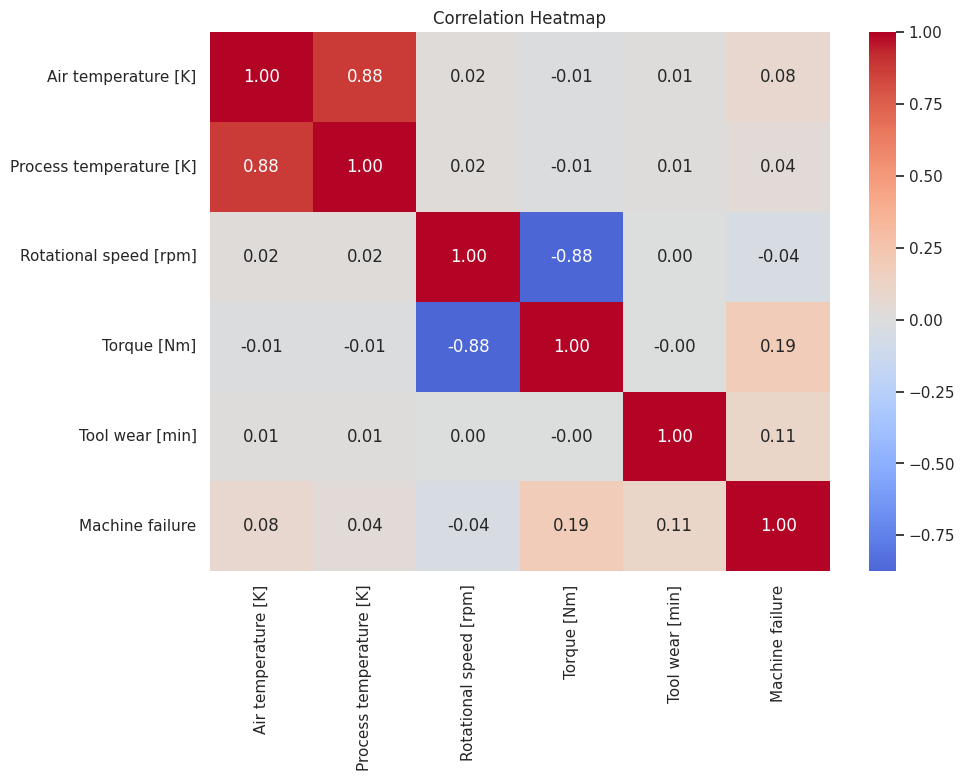

In [13]:
corr_cols = numeric_columns + ["Machine failure"]

plt.figure(figsize=(10, 7))
sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

## 9. Failure-Mode Analysis and Leakage Check

In [14]:
failure_mode_columns = ["TWF", "HDF", "PWF", "OSF", "RNF"]

print("Failure-mode counts:")
display(df[failure_mode_columns].sum().to_frame("Count"))

print("Failure mode vs Machine Failure:")
for col in failure_mode_columns:
    print(f"\n{col}")
    display(
        pd.crosstab(
            df[col],
            df["Machine failure"],
            normalize="index"
        ).mul(100).round(2)
    )

Failure-mode counts:


,Count
TWF,46
HDF,115
PWF,95
OSF,98
RNF,19


Failure mode vs Machine Failure:

TWF


Machine failure,0,1
TWF,,
0,97.06,2.94
1,0.00,100.00



HDF


...

Machine failure,0,1
PWF,,
0,97.54,2.46
1,0.00,100.00



OSF


Machine failure,0,1
OSF,,
0,97.57,2.43
1,0.00,100.00



RNF


Machine failure,0,1
RNF,,
0,96.61,3.39
1,94.74,5.26


### Modeling decision

We exclude:

- `UDI` — identifier
- `Product ID` — identifier
- `Machine failure` — target
- `TWF`, `HDF`, `PWF`, `OSF`, `RNF` — failure-mode indicators that can leak information about the target

We retain `Type` because it is a meaningful categorical machine/product characteristic.

The model therefore has to learn failure patterns from operating conditions rather than being given the failure mechanism.

In [15]:
# Check numerical ranges before modeling
display(
    df[numeric_columns].agg(["min", "max", "mean", "median", "std"]).T
)

,min,max,mean,median,std
Air temperature [K],295.3,304.5,300.00493,300.1,2.000259
Process temperature [K],305.7,313.8,310.00556,310.1,1.483734
Rotational speed [rpm],1168.0,2886.0,1538.77610,1503.0,179.284096
Torque [Nm],3.8,76.6,39.98691,40.1,9.968934
Tool wear [min],0.0,253.0,107.95100,108.0,63.654147


## 10. Feature Engineering

In [16]:
model_df = df.copy()

# Temperature difference
model_df["Temperature Difference [K]"] = (
    model_df["Process temperature [K]"]
    - model_df["Air temperature [K]"]
)

# Mechanical power:
# P = torque × angular velocity
# rpm -> rad/s using 2*pi/60
model_df["Mechanical Power [W]"] = (
    model_df["Torque [Nm]"]
    * model_df["Rotational speed [rpm]"]
    * (2 * np.pi / 60)
)

# Simple operating-condition relationships
model_df["Torque per Speed"] = (
    model_df["Torque [Nm]"]
    / (model_df["Rotational speed [rpm]"] + 1e-6)
)

model_df["Thermal Wear Load"] = (
    model_df["Temperature Difference [K]"]
    * model_df["Tool wear [min]"]
)

engineered_columns = [
    "Temperature Difference [K]",
    "Mechanical Power [W]",
    "Torque per Speed",
    "Thermal Wear Load"
]

display(model_df[engineered_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
Temperature Difference [K],10000.0,10.000630,1.001094,7.600000,9.300000,9.800000,11.000000,12.100000
Mechanical Power [W],10000.0,6279.744953,1067.418295,1148.440610,5561.184484,6271.027344,7003.002724,10469.923005
Torque per Speed,10000.0,0.026895,0.008838,0.001317,0.020640,0.026735,0.032805,0.063833
Thermal Wear Load,10000.0,1079.088090,647.747153,0.000000,524.400000,1068.700000,1610.400000,2880.000000


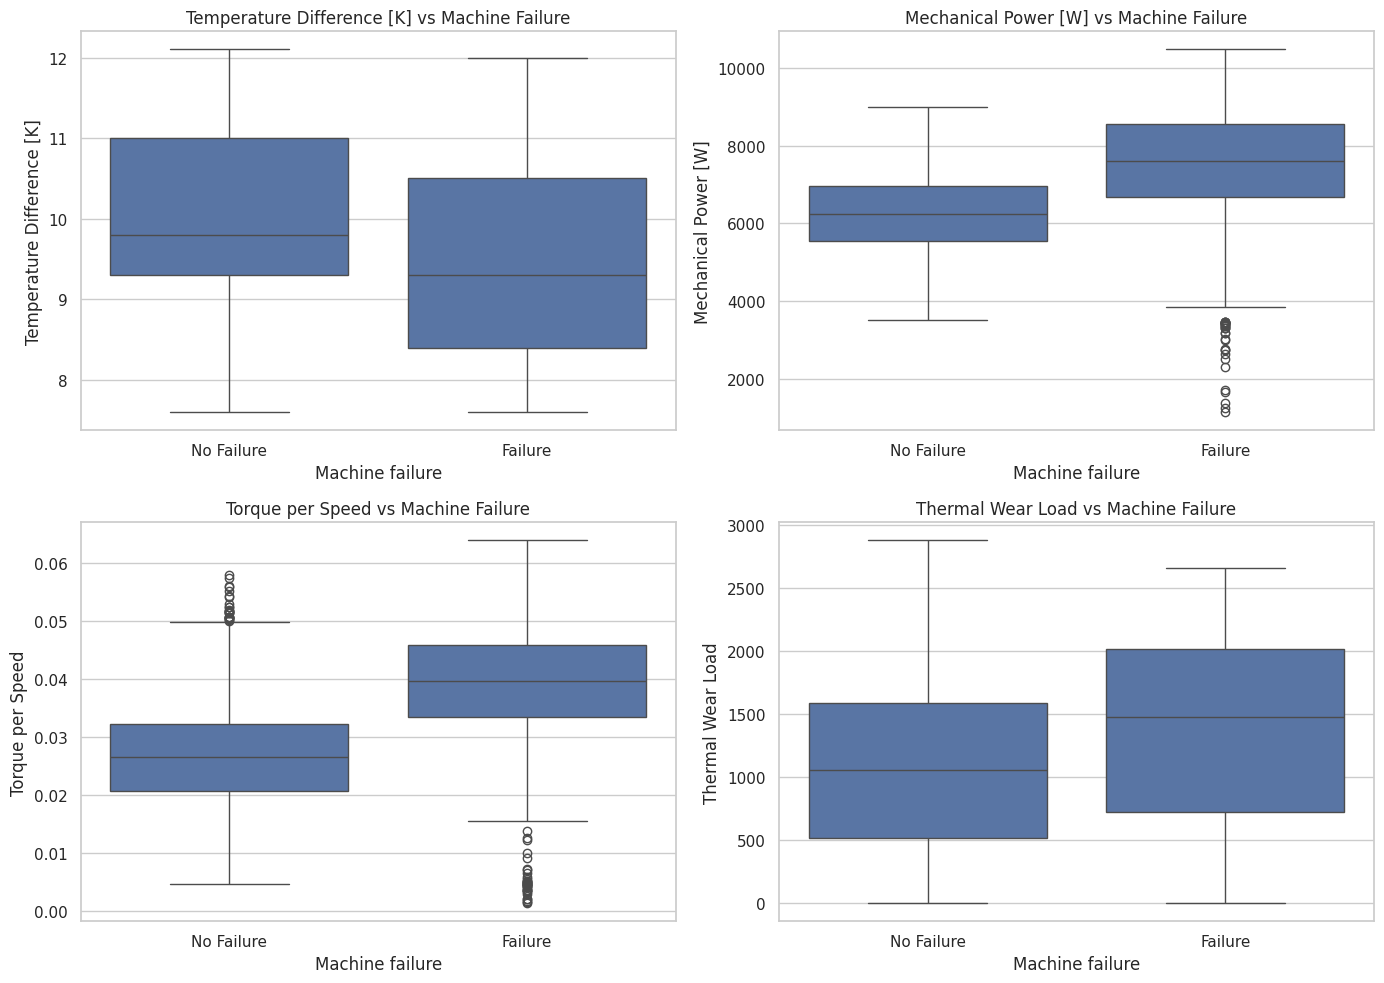

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.ravel(), engineered_columns):
    sns.boxplot(data=model_df, x="Machine failure", y=col, ax=ax)
    ax.set_title(f"{col} vs Machine Failure")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No Failure", "Failure"])

plt.tight_layout()
plt.show()

## 11. Prepare Features and Target

In [18]:
TARGET = "Machine failure"

DROP_COLUMNS = [
    "UDI",
    "Product ID",
    "Machine failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

X = model_df.drop(columns=DROP_COLUMNS)
y = model_df[TARGET]

print("Features used:")
print(X.columns.tolist())
print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features used:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temperature Difference [K]', 'Mechanical Power [W]', 'Torque per Speed', 'Thermal Wear Load']

X shape: (10000, 10)
y shape: (10000,)


## 12. Train/Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

print("\nTraining target proportions:")
display(y_train.value_counts(normalize=True).rename("Proportion"))

print("\nTesting target proportions:")
display(y_test.value_counts(normalize=True).rename("Proportion"))

Training set: (8000, 10)
Testing set : (2000, 10)

Training target proportions:


,Proportion
Machine failure,
0,0.966125
1,0.033875



Testing target proportions:


,Proportion
Machine failure,
0,0.966
1,0.034


## 13. Preprocessing Pipeline

In [20]:
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

Categorical features: ['Type']
Numerical features: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temperature Difference [K]', 'Mechanical Power [W]', 'Torque per Speed', 'Thermal Wear Load']


## 14. Define the Six Models

In [21]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),

    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
}

for name in models:
    print("-", name)

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- XGBoost
- SVM


## 15. Baseline Model Comparison

In [22]:
def evaluate_pipeline(name, model):
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    pred = pipeline.predict(X_test)
    prob = pipeline.predict_proba(X_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "Specificity": specificity,
        "ROC-AUC": roc_auc_score(y_test, prob),
        "PR-AUC": average_precision_score(y_test, prob)
    }

    return result, pipeline, pred, prob


baseline_results = []
baseline_pipelines = {}

for name, model in models.items():
    result, pipeline, pred, prob = evaluate_pipeline(name, model)
    baseline_results.append(result)
    baseline_pipelines[name] = pipeline

baseline_df = pd.DataFrame(baseline_results).sort_values(
    "F1", ascending=False
)

display(baseline_df.round(4))

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,Specificity,ROC-AUC,PR-AUC
3,Gradient Boosting,0.9920,0.8894,0.9815,0.7794,0.8689,0.9995,0.9755,0.8960
4,XGBoost,0.9885,0.8734,0.8947,0.7500,0.8160,0.9969,0.9836,0.8777
2,Random Forest,0.9880,0.8448,0.9400,0.6912,0.7966,0.9984,0.9793,0.8592
1,Decision Tree,0.9830,0.8564,0.7656,0.7206,0.7424,0.9922,0.8564,0.5612
5,SVM,0.9230,0.9247,0.2972,0.9265,0.4500,0.9229,0.9697,0.6400
0,Logistic Regression,0.8660,0.8526,0.1815,0.8382,0.2984,0.8670,0.9370,0.5098


## 16. GridSearchCV Hyperparameter Tuning

In [23]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

param_grids = {

    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10],
        "model__solver": ["liblinear"]
    },

    "Decision Tree": {
        "model__max_depth": [3, 5, 8, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 5]
    },

    "Random Forest": {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2]
    },

    "Gradient Boosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.03, 0.1],
        "model__max_depth": [2, 3]
    },

    "XGBoost": {
        "model__n_estimators": [200, 400],
        "model__learning_rate": [0.03, 0.1],
        "model__max_depth": [3, 5],
        "model__min_child_weight": [1, 3],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0]
    },

    "SVM": {
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", "auto"]
    }
}

In [24]:
# Show how large each grid is

grid_summary = []

for name, grid in param_grids.items():
    combinations = len(list(ParameterGrid(grid)))

    grid_summary.append({
        "Model": name,
        "Parameter Combinations": combinations,
        "CV Folds": cv.n_splits,
        "Total Fits": combinations * cv.n_splits
    })

display(pd.DataFrame(grid_summary))

,Model,Parameter Combinations,CV Folds,Total Fits
0,Logistic Regression,4,5,20
1,Decision Tree,36,5,180
2,Random Forest,24,5,120
3,Gradient Boosting,8,5,40
4,XGBoost,64,5,320
5,SVM,6,5,30


In [ ]:
tuned_models = {}
tuning_summary = []

for name, model in models.items():

    print("=" * 70)
    print(f"Tuning {name}")
    print("=" * 70)

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=False
    )

    search.fit(X_train, y_train)

    tuned_models[name] = search

    tuning_summary.append({
        "Model": name,
        "Best CV F1": search.best_score_,
        "Best Parameters": search.best_params_
    })

    print("Best CV F1:", round(search.best_score_, 4))
    print("Best Parameters:", search.best_params_)

tuning_df = pd.DataFrame(tuning_summary).sort_values(
    "Best CV F1", ascending=False
)

display(tuning_df)

Tuning Logistic Regression
Best CV F1: 0.3002
Best Parameters: {'model__C': 1, 'model__solver': 'liblinear'}
Tuning Decision Tree
Best CV F1: 0.7534
Best Parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Tuning Random Forest
Best CV F1: 0.8147
Best Parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 400}
Tuning Gradient Boosting


## 17. Tuned Model Comparison

In [ ]:
tuned_results = []
test_predictions = {}
test_probabilities = {}

for name, search in tuned_models.items():

    best_pipeline = search.best_estimator_

    pred = best_pipeline.predict(X_test)
    prob = best_pipeline.predict_proba(X_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "Specificity": specificity,
        "ROC-AUC": roc_auc_score(y_test, prob),
        "PR-AUC": average_precision_score(y_test, prob),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

    test_predictions[name] = pred
    test_probabilities[name] = prob

tuned_results_df = pd.DataFrame(tuned_results).sort_values(
    ["F1", "PR-AUC"],
    ascending=False
)

display(tuned_results_df.round(4))

In [ ]:
metrics_to_plot = [
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
]

plt.figure(figsize=(14, 7))

tuned_results_df.set_index("Model")[metrics_to_plot].plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Tuned Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 18. Select the Best Model

In [ ]:
best_model_name = tuned_results_df.iloc[0]["Model"]

best_search = tuned_models[best_model_name]
best_model = best_search.best_estimator_

best_pred = test_predictions[best_model_name]
best_prob = test_probabilities[best_model_name]

print("Best model:", best_model_name)
print("Best CV F1:", round(best_search.best_score_, 4))

print("\nBest hyperparameters:")
for parameter, value in best_search.best_params_.items():
    print(f"{parameter}: {value}")

## 19. Detailed Evaluation

In [ ]:
print(classification_report(
    y_test,
    best_pred,
    target_names=["No Failure", "Failure"],
    digits=4
))

print("Accuracy          :", round(accuracy_score(y_test, best_pred), 4))
print("Balanced Accuracy :", round(balanced_accuracy_score(y_test, best_pred), 4))
print("Precision         :", round(precision_score(y_test, best_pred), 4))
print("Recall            :", round(recall_score(y_test, best_pred), 4))
print("F1 Score          :", round(f1_score(y_test, best_pred), 4))
print("ROC-AUC           :", round(roc_auc_score(y_test, best_prob), 4))
print("PR-AUC            :", round(average_precision_score(y_test, best_prob), 4))

## 20. Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, best_pred)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)

plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

print("\nSpecificity:", round(tn / (tn + fp), 4))

### What the confusion matrix means

In [ ]:
print("TN:", tn, "→ Healthy machine correctly identified")
print("FP:", fp, "→ Healthy machine incorrectly flagged as failure")
print("FN:", fn, "→ Actual failure missed by the model")
print("TP:", tp, "→ Actual failure correctly detected")

print("\nIn predictive maintenance, FN is especially important because it represents a failure that was missed.")

## 21. ROC Curve

In [ ]:
fpr, tpr, _ = roc_curve(y_test, best_prob)
roc_auc = roc_auc_score(y_test, best_prob)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    label=f"{best_model_name} (AUC = {roc_auc:.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 22. Precision-Recall Curve

In [ ]:
precision, recall, _ = precision_recall_curve(
    y_test,
    best_prob
)

pr_auc = average_precision_score(
    y_test,
    best_prob
)

plt.figure(figsize=(8, 6))
plt.plot(
    recall,
    precision,
    label=f"PR-AUC = {pr_auc:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

## 23. Predicted Failure Probability Analysis

In [ ]:
probability_df = pd.DataFrame({
    "Failure Probability": best_prob,
    "Actual": y_test.values
})

plt.figure(figsize=(10, 6))

sns.histplot(
    data=probability_df,
    x="Failure Probability",
    hue="Actual",
    bins=30,
    kde=True,
    element="step"
)

plt.axvline(
    0.50,
    linestyle="--",
    label="Default Threshold = 0.50"
)

plt.title("Predicted Probability of Machine Failure")
plt.xlabel("Probability of Failure")
plt.legend()
plt.show()

## 24. Decision Threshold Analysis

In [ ]:
threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):

    threshold_pred = (
        best_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(
            y_test,
            threshold_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            threshold_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            threshold_pred,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df.round(4))

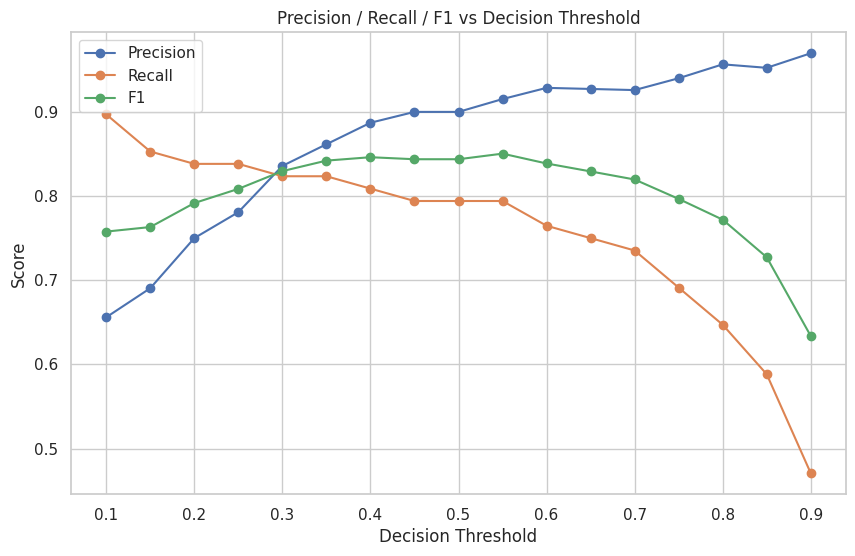

Best F1 threshold on the test split: 0.55


In [36]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Decision Threshold")
plt.legend()
plt.show()

best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print("Best F1 threshold on the test split:",
      best_threshold_row["Threshold"])

> **Important:** The threshold analysis above is for understanding model behavior. For a strictly unbiased final evaluation, the operating threshold should be selected using validation data/CV and then applied once to the untouched test set.

## 25. Feature Importance

,Feature,Importance
5,numeric__Temperature Difference [K],0.196476
6,numeric__Mechanical Power [W],0.158262
2,numeric__Rotational speed [rpm],0.124147
4,numeric__Tool wear [min],0.119132
7,numeric__Torque per Speed,0.110508
3,numeric__Torque [Nm],0.087315
10,categorical__Type_L,0.080940
8,numeric__Thermal Wear Load,0.049752
0,numeric__Air temperature [K],0.024828
11,categorical__Type_M,0.019911


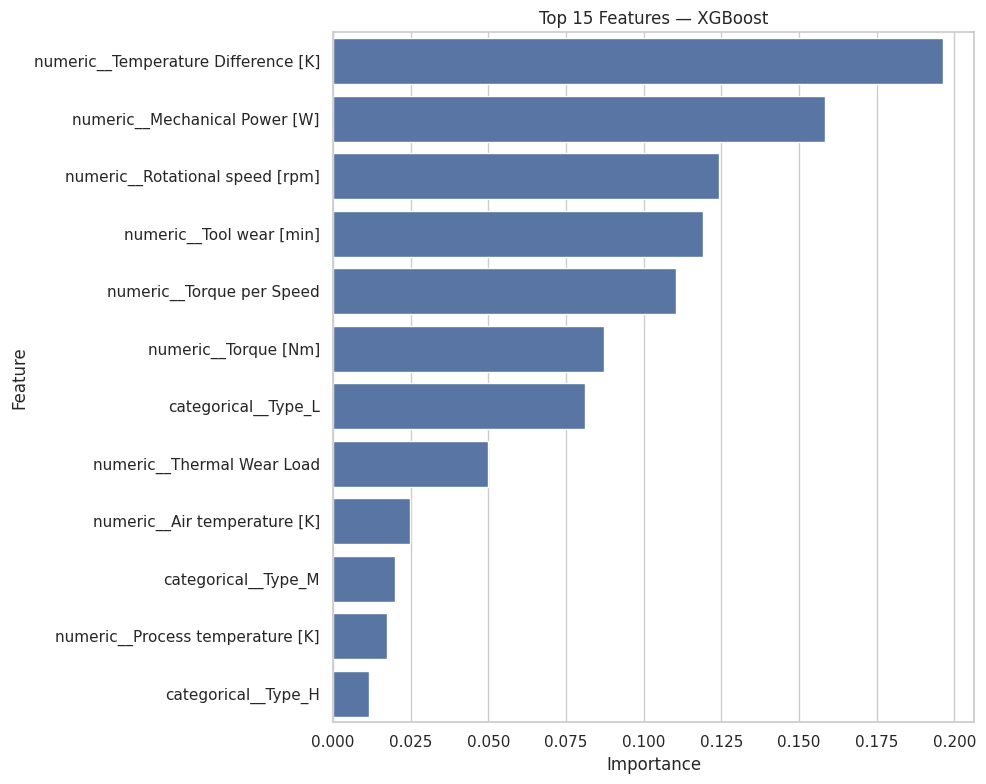

In [37]:
model_step = best_model.named_steps["model"]
feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

if hasattr(model_step, "feature_importances_"):

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model_step.feature_importances_
    }).sort_values(
        "Importance",
        ascending=False
    )

    display(importance_df.head(20))

    plt.figure(figsize=(10, 8))

    sns.barplot(
        data=importance_df.head(15),
        x="Importance",
        y="Feature"
    )

    plt.title(f"Top 15 Features — {best_model_name}")
    plt.tight_layout()
    plt.show()

elif hasattr(model_step, "coef_"):

    coefficient_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": model_step.coef_[0],
        "Absolute Importance": np.abs(model_step.coef_[0])
    }).sort_values(
        "Absolute Importance",
        ascending=False
    )

    display(coefficient_df.head(20))

else:
    print("Native feature importance is not available.")

## 26. False Positive / False Negative Analysis

In [38]:
error_analysis = X_test.copy()

error_analysis["Actual"] = y_test.values
error_analysis["Predicted"] = best_pred
error_analysis["Failure Probability"] = best_prob

error_analysis["Result"] = np.select(
    [
        (error_analysis["Actual"] == 1) &
        (error_analysis["Predicted"] == 1),

        (error_analysis["Actual"] == 0) &
        (error_analysis["Predicted"] == 0),

        (error_analysis["Actual"] == 1) &
        (error_analysis["Predicted"] == 0),

        (error_analysis["Actual"] == 0) &
        (error_analysis["Predicted"] == 1)
    ],
    [
        "True Positive",
        "True Negative",
        "False Negative",
        "False Positive"
    ],
    default="Unknown"
)

display(
    error_analysis["Result"]
    .value_counts()
    .to_frame("Count")
)

,Count
Result,
True Negative,1926
True Positive,54
False Negative,14
False Positive,6


In [39]:
print("FALSE NEGATIVES")
print("=" * 60)

display(
    error_analysis[
        error_analysis["Result"] == "False Negative"
    ].sort_values(
        "Failure Probability",
        ascending=False
    ).head(15)
)

print("\nFALSE POSITIVES")
print("=" * 60)

display(
    error_analysis[
        error_analysis["Result"] == "False Positive"
    ].sort_values(
        "Failure Probability",
        ascending=False
    ).head(15)
)

FALSE NEGATIVES


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temperature Difference [K],Mechanical Power [W],Torque per Speed,Thermal Wear Load,Actual,Predicted,Failure Probability,Result
7884,L,300.8,312.4,1465,59.1,91,11.6,9066.793478,0.040341,1055.6,1,0,0.427458,False Negative
4034,L,302.0,310.8,1615,29.0,235,8.8,4904.549731,0.017957,2068.0,1,0,0.354188,False Negative
2864,H,300.6,309.4,1380,47.6,246,8.8,6878.831274,0.034493,2164.8,1,0,0.284276,False Negative
9015,L,297.2,308.1,1431,49.7,210,10.9,7447.742288,0.034731,2289.0,1,0,0.180362,False Negative
4778,H,303.6,312.2,1371,54.6,112,8.6,7838.964821,0.039825,963.2,1,0,0.125834,False Negative
1833,L,297.8,307.3,1327,61.0,186,9.5,8476.750018,0.045968,1767.0,1,0,0.120250,False Negative
7849,M,300.3,311.7,1374,47.9,222,11.4,6892.088795,0.034862,2530.8,1,0,0.111522,False Negative
3695,L,302.2,311.3,1530,37.3,207,9.1,5976.251705,0.024379,1883.7,1,0,0.066324,False Negative
7087,L,300.6,310.3,1648,30.5,217,9.7,5263.633771,0.018507,2104.9,1,0,0.024141,False Negative
2671,M,299.7,309.3,1399,41.9,221,9.6,6138.473078,0.029950,2121.6,1,0,0.014270,False Negative



FALSE POSITIVES


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temperature Difference [K],Mechanical Power [W],Torque per Speed,Thermal Wear Load,Actual,Predicted,Failure Probability,Result
3794,M,302.2,310.8,1356,48.3,36,8.6,6858.599418,0.035619,309.6,0,1,0.924465,False Positive
7677,L,300.6,311.7,1428,52.6,208,11.1,7865.794022,0.036835,2308.8,0,1,0.861120,False Positive
4231,L,302.2,310.8,1340,47.8,54,8.6,6707.509755,0.035672,464.4,0,1,0.794656,False Positive
8607,L,297.5,308.4,1433,50.0,218,10.9,7503.170454,0.034892,2376.2,0,1,0.713329,False Positive
7086,L,300.6,310.4,2514,13.4,215,9.8,3527.757223,0.005330,2107.0,0,1,0.596333,False Positive
1418,L,298.8,309.9,1320,47.4,210,11.1,6552.105638,0.035909,2331.0,0,1,0.520223,False Positive


## 27. Final Project Summary

In [40]:
final_row = tuned_results_df[
    tuned_results_df["Model"] == best_model_name
].iloc[0]

print("=" * 70)
print("FINAL MODEL SUMMARY")
print("=" * 70)

print(f"Best Model        : {best_model_name}")
print(f"Accuracy          : {final_row['Accuracy']:.4f}")
print(f"Balanced Accuracy : {final_row['Balanced Accuracy']:.4f}")
print(f"Precision         : {final_row['Precision']:.4f}")
print(f"Recall            : {final_row['Recall']:.4f}")
print(f"F1 Score          : {final_row['F1']:.4f}")
print(f"Specificity       : {final_row['Specificity']:.4f}")
print(f"ROC-AUC           : {final_row['ROC-AUC']:.4f}")
print(f"PR-AUC            : {final_row['PR-AUC']:.4f}")

print("\nConfusion Matrix:")
print(f"TN = {int(final_row['TN'])}")
print(f"FP = {int(final_row['FP'])}")
print(f"FN = {int(final_row['FN'])}")
print(f"TP = {int(final_row['TP'])}")

FINAL MODEL SUMMARY
Best Model        : XGBoost
Accuracy          : 0.9900
Balanced Accuracy : 0.8955
Precision         : 0.9000
Recall            : 0.7941
F1 Score          : 0.8438
Specificity       : 0.9969
ROC-AUC           : 0.9815
PR-AUC            : 0.8835

Confusion Matrix:
TN = 1926
FP = 6
FN = 14
TP = 54


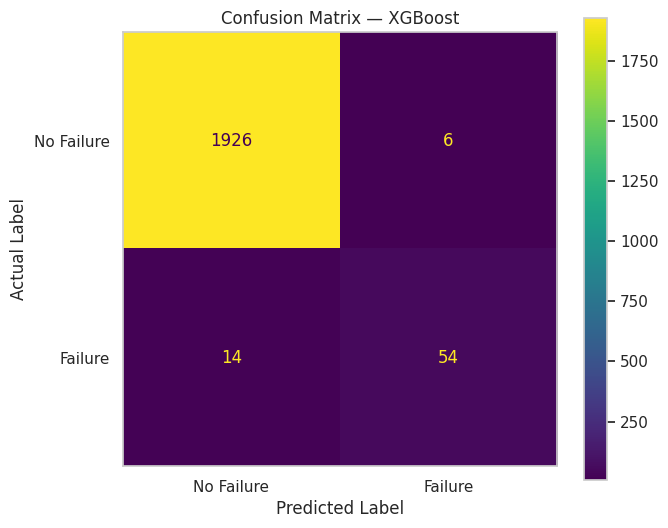

In [42]:
# Graphical Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred,
    display_labels=["No Failure", "Failure"],
    values_format="d",
    ax=ax
)

# To Remove the grid lines, grey ones that were coming
ax.grid(False)

plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# 28. Conclusions

The completed pipeline answers:

> **Can machine operating conditions be used to distinguish observations associated with machine failure from observations associated with no failure?**

The model learns from:

- Product type
- Air temperature
- Process temperature
- Rotational speed
- Torque
- Tool wear
- Temperature difference
- Mechanical power
- Torque/speed relationship
- Thermal-wear load

The target is:

- `0` → No Failure
- `1` → Failure

### Important evaluation metrics

**Precision:** Of the machines predicted to fail, how many actually failed?

**Recall:** Of the machines that actually failed, how many did we detect?

**F1:** Balance between precision and recall.

**Specificity:** How well do we identify healthy machines?

**ROC-AUC:** Overall ranking ability across thresholds.

**PR-AUC:** Especially useful when failure is the minority class.

### Final modeling decisions

- Six practical ML models were compared.
- XGBoost was included and tuned with GridSearchCV.
- Extra Trees and HistGradientBoosting were intentionally omitted to keep the project focused.
- Failure-mode columns were excluded to avoid leakage.
- No model export or Flask integration is included.